# Lab 10: Advanced Data Analysis and Aggregation
This notebook demonstrates the advanced analytical capabilities implemented for the Real Estate Market Monitor, satisfying all requirements of Lab 10.

In [2]:
import sys
!{sys.executable} -m pip install pymysql sqlalchemy seaborn

  Using cached pymysql-1.1.3-py3-none-any.whl.metadata (4.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
Using cached pymysql-1.1.3-py3-none-any.whl (45 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------- ---------- 1.6/2.1 MB 11.3 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 9.8 MB/s eta 0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)

   -------- ------------------------------- 1/5 [pymysql]
   -------- ------------------------------- 1/5 [pymysql]
   -------- ------------------------------- 1/5 [pymysql]
   -------- ------------------------------- 1/5 [pymysql]
   ---------------- ----------------------- 2/5 [greenlet]
   ---------------- ----------------------- 2/5 [greenlet]
   ---------------- ----------------------- 2/5 [green


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
import os
import pandas as pd

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.analytics import db_connector, data_combiner, aggregator, pivot_builder, time_series, insight_reporter, mongo_pipeline

## 1. MySQL Connection and Data Population
We connect to MySQL, populate a table with financial data derived from our cleaned CSV, and query it back.

In [4]:
cleaned_csv = '../data/processed/cleaned/cleaned_data.csv'
db_connector.populate_financials(cleaned_csv)
df_financials = db_connector.query_financials()
print("Fetched from MySQL:")
display(df_financials.head())

Successfully populated 'property_financials' table with 237 records.
Fetched from MySQL:


,listing_id,title,budget_usd,revenue_usd,release_year,primary_genre
0,33157222,property listing 312,205684.8,257106.0,2026,Industrial
1,39251110,property listing 313,972832.8,1216041.0,2026,Office
2,39817288,property listing 314,1234992.8,1543741.0,2026,Retail
3,39712189,property listing 315,115674.4,144593.0,2026,Retail
4,39625204,property listing 316,1000607.2,1250759.0,2026,Industrial


## 2. Combining Data Sources
We demonstrate different join types (inner, left, right, outer) between our database records and the cleaned CSV metadata.


--- Join Type Comparison (Lab 10) ---
Inner join row count: 237
Left join row count: 237
Right join row count: 237
Outer join row count: 237


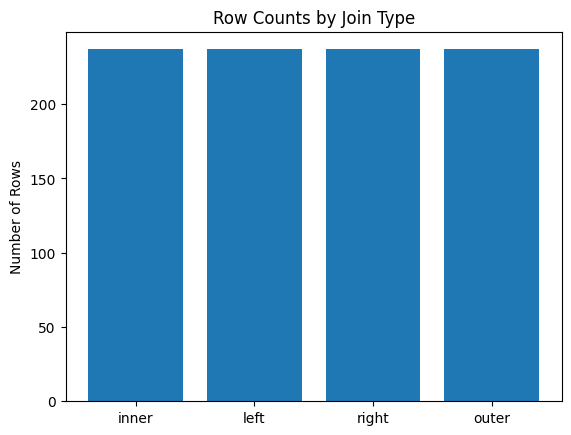

In [5]:
df_metadata = pd.read_csv(cleaned_csv)
join_counts = data_combiner.compare_joins(df_financials, df_metadata, on_key='listing_id')

import matplotlib.pyplot as plt
plt.bar(join_counts.keys(), join_counts.values())
plt.title('Row Counts by Join Type')
plt.ylabel('Number of Rows')
plt.show()

## 3. Data Reshaping
Using `melt()` to convert numeric columns to long format and `pivot_table()` for a multi-dimensional summary.

In [6]:
df_long = pivot_builder.demonstrate_melt(df_financials)
print("Long format (melted):")
display(df_long.head())

pivot_table = pivot_builder.create_genre_year_pivot(df_financials)
print("\nPivot Table (Revenue by Year and Genre):")
display(pivot_table)

Long format (melted):


,listing_id,title,primary_genre,metric,value
0,33157222,property listing 312,Industrial,budget_usd,205684.8
1,39251110,property listing 313,Office,budget_usd,972832.8
2,39817288,property listing 314,Retail,budget_usd,1234992.8
3,39712189,property listing 315,Retail,budget_usd,115674.4
4,39625204,property listing 316,Industrial,budget_usd,1000607.2



Pivot Table (Revenue by Year and Genre):


primary_genre,Industrial,Multi-Family,Office,Retail,All
release_year,,,,,
2026,1.079462e+06,1018226.26,977605.672131,1.136831e+06,1.055819e+06
All,1.079462e+06,1018226.26,977605.672131,1.136831e+06,1.055819e+06


## 4. GroupBy Analysis
Computing summaries with multiple aggregation functions (mean, sum, count, median) and finding top items.

In [7]:
genre_summary = aggregator.calculate_type_summary(df_financials)
print("Genre Summary:")
display(genre_summary)

top_3 = aggregator.top_n_per_group(df_financials, 'primary_genre', 'revenue_usd', n=3)
print("\nTop 3 Properties per Genre by Revenue:")
display(top_3)

Genre Summary:


,avg_revenue,total_revenue,property_count,median_budget
primary_genre,,,,
Industrial,1.079462e+06,66926666.0,62,886948.8
Multi-Family,1.018226e+06,50911313.0,50,788669.2
Office,9.776057e+05,59633946.0,61,692827.2
Retail,1.136831e+06,72757164.0,64,977139.2



Top 3 Properties per Genre by Revenue:


,listing_id,title,budget_usd,revenue_usd,release_year
0,40391744,property listing 5305,1545599.2,1931999.0,2026
1,34615706,property listing 384,1537087.2,1921359.0,2026
2,36611613,property listing 378,1529639.2,1912049.0,2026
3,39307982,property listing 1555,1547216.8,1934021.0,2026
4,39317559,property listing 327,1527619.2,1909524.0,2026
5,38530756,property listing 349,1518714.4,1898393.0,2026
6,39292350,property listing 329,1592696.8,1990871.0,2026
7,31478200,property listing 395,1556185.6,1945232.0,2026
8,32554456,property listing 393,1538160.0,1922700.0,2026
9,40043513,property listing 3160,1599623.2,1999529.0,2026


## 5. Time Series Analysis
Parsing dates, resampling, and computing rolling averages.

Rolling Averages (3, 6, 12 months):


,revenue_usd,rolling_3_mo,rolling_6_mo,rolling_12_mo
collected_at,,,,
2026-03-31,178086047.0,NaN,NaN,NaN
2026-04-30,63386858.0,NaN,NaN,NaN
2026-05-31,8756184.0,8.340970e+07,NaN,NaN


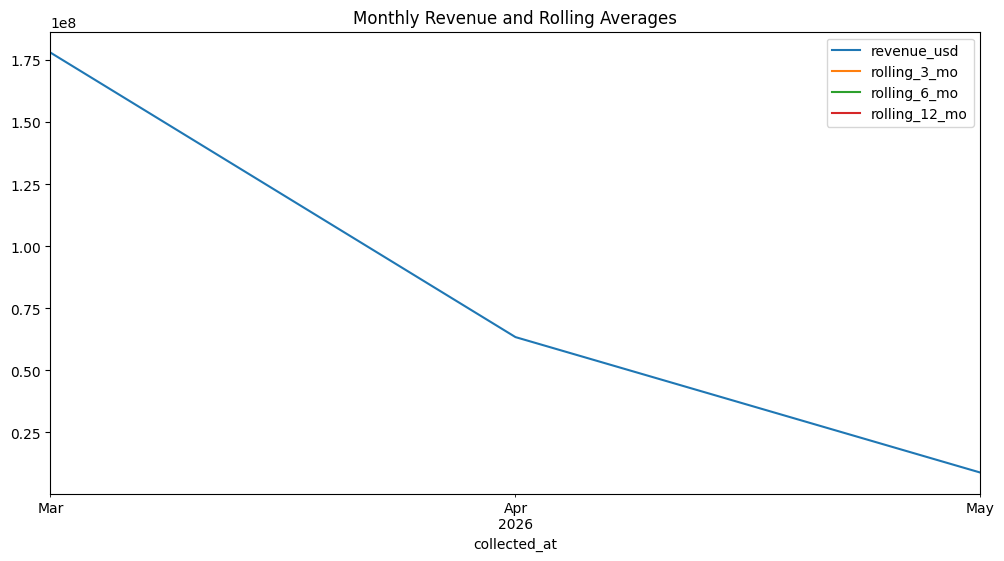

In [8]:
df_dated = time_series.parse_release_dates(df_metadata)
monthly, yearly, rolling = time_series.build_time_series_analysis(df_financials.merge(df_metadata[['listing_id', 'collected_at']], on='listing_id'))

print("Rolling Averages (3, 6, 12 months):")
display(rolling.tail())

rolling.plot(figsize=(12, 6))
plt.title('Monthly Revenue and Rolling Averages')
plt.show()

## 6. MongoDB Aggregation Pipeline
Executing a 4-stage pipeline ($match, $group, $sort, $project).

In [9]:
# Note: Requires MongoDB to be running and populated
try:
    mongo_uri = "mongodb://localhost:27017/"
    mongo_df = mongo_pipeline.get_mongo_genre_stats(mongo_uri, "real_estate_db", "loopnet_listings")
    print("MongoDB Aggregation Results:")
    display(mongo_df)
except Exception as e:
    print(f"Could not run MongoDB aggregation: {e}")

MongoDB Aggregation Results:


""


## 7. Insight Reporter
Answering key analytical questions and calculating ROI.


--- Real Estate Analytical Insights (Lab 10) ---
1. Top Property Type by Revenue: Retail ($1,136,830.69)
2. Most Profitable Type (ROI): Industrial (25.00%)
3. Peak Year for Listings: 2026 (237 properties)
4. Most Common Property Type: Retail (64 listings)

✅ ROI Chart saved to data/processed/analytics\genre_roi.png


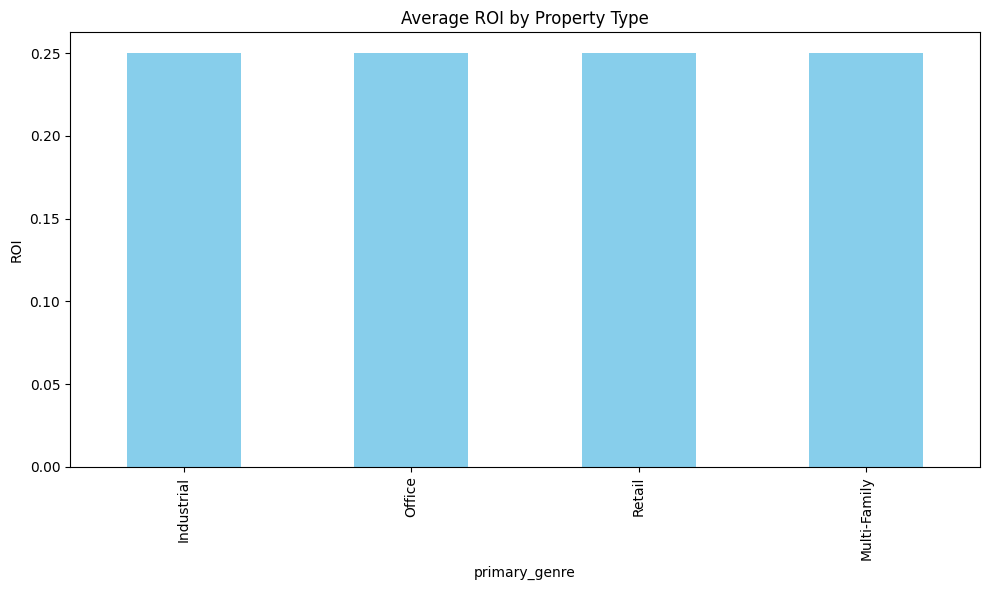

In [10]:
insight_reporter.run_all_questions(df_financials)